In [1]:
from bs4 import BeautifulSoup
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import nltk
from nltk.tokenize import word_tokenize
import os
import tqdm
import numpy as np
import gc
import sys
from sklearn.model_selection import train_test_split

In [ ]:
!pip show torch
!pip show torchtext

In [ ]:
nltk.download('punkt')

In [2]:
# https://data.mendeley.com/datasets/n96ncsr5g4/1

regex = re.compile(r"\((\d+), '([^']+)', '([^']+)', (\d+), ('[^']+'\))")

mapper = dict()

with open('n96ncsr5g4-1/index.txt', 'r') as file:
    fields = file.readlines()
    for field in fields:
        match = re.match(regex, field)
        if match:
            mapper[match.group(3)] = match.group(4)

print(len(mapper))


79987


In [3]:
# https://data.mendeley.com/datasets/n96ncsr5g4/1

files = []

for part in range(1, 7):  # Dataset parts 1 to 6
    dataset_path = f'n96ncsr5g4-1/dataset/dataset-part-{part}'
    for file in os.listdir(dataset_path):
        full_path = f'{dataset_path}/{file}'
        files.append(full_path)

X = []
y = []
max_files = 10000
ben_files_max = 100
phi_files_max = 6000

for file in tqdm.tqdm(files[:max_files]):
    # Extract the filename from the full path
    filename = file.split('/')[-1]
    if filename in mapper and phi_files_max > 0:
        with open(file, 'r') as _file:
            html_content = _file.read()
            soup = BeautifulSoup(html_content, 'html.parser')
            text = soup.get_text()
            text = text.strip()
            X.append(text)
            y.append(mapper[filename])
            phi_files_max -= 1
    if filename in mapper and ben_files_max > 0:
        with open(file, 'r') as _file:
            html_content = _file.read()
            soup = BeautifulSoup(html_content, 'html.parser')
            text = soup.get_text()
            text = text.strip()
            X.append(text)
            y.append(mapper[filename])
            ben_files_max -= 1

100%|██████████| 10000/10000 [01:20<00:00, 124.71it/s]


In [4]:
# https://www.kaggle.com/datasets/huntingdata11/phishing-website-html-classification?resource=download

Xdiff = []
ydiff = []
for phase in ['training', 'validation']:
    for label in ['NotPhish', 'Phish']:
        dirpath = os.path.join('archive', phase, label)
        for file in tqdm.tqdm(os.listdir(dirpath)):
            with open(os.path.join(dirpath, file), 'r', encoding='utf-8', errors='replace') as file:
                html_content = file.read()
                soup = BeautifulSoup(html_content, 'html.parser')
                text = soup.get_text()
                text = text.strip()
                Xdiff.append(text)
                ydiff.append(0 if label == 'NotPhish' else 1)

100%|██████████| 1055/1055 [00:14<00:00, 71.25it/s]


In [14]:
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from data.DataLoader import DataLoader as DL
from data.Elastic import Elastic

In [ ]:
dloader = DL(
    Elastic(timeout=5), 
    index='featext2'
)

### Exploratory Data Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Create a list to store the analysis results
analysis_results = []

for i, (text, label) in enumerate(zip(X, y)):
    # Count words and characters
    words = word_tokenize(text)
    chars = list(text)
    
    # Count unique words and characters
    unique_words = set(words)
    unique_chars = set(chars)
    
    # Store the results
    analysis_results.append({
        'File Index': i,
        'Label': label,
        'Word Count': len(words),
        'Character Count': len(chars),
        'Unique Word Count': len(unique_words),
        'Unique Character Count': len(unique_chars)
    })

# Convert to DataFrame for easy analysis
df = pd.DataFrame(analysis_results)

# Display summary statistics
print(df.describe())

# Plot histograms
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
df['Word Count'].hist(ax=axs[0, 0], bins=20)
axs[0, 0].set_title('Distribution of Word Counts')
df['Character Count'].hist(ax=axs[0, 1], bins=20)
axs[0, 1].set_title('Distribution of Character Counts')
df['Unique Word Count'].hist(ax=axs[1, 0], bins=20)
axs[1, 0].set_title('Distribution of Unique Word Counts')
df['Unique Character Count'].hist(ax=axs[1, 1], bins=20)
axs[1, 1].set_title('Distribution of Unique Character Counts')
plt.tight_layout()
plt.show()

# Display top 10 most common words and characters across all files
all_words = [word for text in X for word in text.split()]
all_chars = [char for text in X for char in list(text)]

print("\nTop 10 most common words:")
print(Counter(all_words).most_common(10))

print("\nTop 10 most common characters:")
print(Counter(all_chars).most_common(10))

# Calculate and display average word length
avg_word_length = sum(len(word) for word in all_words) / len(all_words)
print(f"\nAverage word length: {avg_word_length:.2f} characters")


In [ ]:
# Analyze non-alphanumeric characters in files
non_alphanumeric_analysis = []

for i, text in enumerate(X):
    non_alphanumeric = set(char for char in text if not char.isalnum() and not char.isspace())
    if non_alphanumeric:
        non_alphanumeric_analysis.append({
            'File Index': i,
            'Non-alphanumeric Characters': list(non_alphanumeric)
        })

# List all unique non-alphanumeric characters
all_non_alphanumeric = set(char for item in non_alphanumeric_analysis for char in item['Non-alphanumeric Characters'])
print("All non-alphanumeric characters found:")
print(', '.join(sorted(all_non_alphanumeric)))


In [ ]:
# Analyze unique words across all files
all_unique_words = set(word for text in X for word in word_tokenize(text))

print(f"\nTotal number of unique words across all files: {len(all_unique_words)}")

# Display some statistics about word lengths
word_lengths = [len(word) for word in all_unique_words]
avg_word_length = sum(word_lengths) / len(word_lengths)
max_word_length = max(word_lengths)
min_word_length = min(word_lengths)

print(f"Average length of unique words: {avg_word_length:.2f} characters")
print(f"Longest word length: {max_word_length} characters")
print(f"Shortest word length: {min_word_length} characters")

# Display distribution of word lengths
plt.figure(figsize=(10, 5))
plt.hist(word_lengths, bins=range(min_word_length, max_word_length + 2, 1))
plt.title('Distribution of Unique Word Lengths')
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.show()

# Display some examples of long and short words
long_words = [word for word in all_unique_words if len(word) == max_word_length]
short_words = [word for word in all_unique_words if len(word) == min_word_length]

print(f"\nExamples of longest words (length {max_word_length}):")
print(', '.join(long_words[:10]))  # Display up to 10 examples

print(f"\nExamples of shortest words (length {min_word_length}):")
print(', '.join(short_words[:10]))  # Display up to 10 examples


In [ ]:
# Analyze non-ASCII words and their frequencies
from collections import Counter
import unicodedata

def is_ascii(s):
    return all(ord(c) < 128 for c in s)

non_ascii_words = [word for text in X for word in word_tokenize(text) if not is_ascii(word)]
non_ascii_word_freq = Counter(non_ascii_words)

print(f"Total number of unique non-ASCII words: {len(non_ascii_word_freq)}")

# Sort non-ASCII words by frequency (descending order)
sorted_non_ascii_words = sorted(non_ascii_word_freq.items(), key=lambda x: x[1], reverse=True)

print("\nTop 20 most frequent non-ASCII words and their frequencies:")
for word, freq in sorted_non_ascii_words[:20]:
    print(f"{word}: {freq}")

# Function to get Unicode category for a character
def get_unicode_category(char):
    return unicodedata.category(char)

# Analyze Unicode categories of non-ASCII characters
non_ascii_char_categories = Counter()
for word in non_ascii_words:
    for char in word:
        if not is_ascii(char):
            non_ascii_char_categories[get_unicode_category(char)] += 1

print("\nUnicode categories of non-ASCII characters:")
for category, count in non_ascii_char_categories.most_common():
    print(f"{category}: {count}")


### Vocab Builder from Iterator

In [5]:
# Based on torchtext build_vocab_from_iterator function

from collections import Counter, defaultdict

class Vocab:
    """A simple vocabulary object to map tokens to numerical identifiers."""

    UNK = '<unk>'

    def __init__(self, counter, max_size=None, min_freq=1, specials=('<unk>', '<pad>')):
        """Initialize the Vocab object from a counter of token frequencies."""
        self.freqs = counter
        self.itos = list(specials)  # Initialize with special tokens
        self.unk_index = self.itos.index(Vocab.UNK) if Vocab.UNK in specials else None
        min_freq = max(min_freq, 1)

        # Remove special tokens from the counter
        for special in specials:
            del counter[special]

        # Sort by frequency (descending), then alphabetically
        words_and_frequencies = sorted(counter.items(), key=lambda tup: (-tup[1], tup[0]))

        # Add tokens to the vocabulary, respecting max_size and min_freq
        for word, freq in words_and_frequencies:
            if freq < min_freq or (max_size is not None and len(self.itos) >= max_size):
                break
            self.itos.append(word)

        # Create the stoi mapping (string-to-index)
        self.stoi = defaultdict(lambda: self.unk_index, {tok: i for i, tok in enumerate(self.itos)})

    def set_default_index(self, index):
        """Set the default index to use for unknown tokens."""
        self.unk_index = index
        # Update the defaultdict to use the new default index
        self.stoi = defaultdict(lambda: self.unk_index, self.stoi)

    def __getitem__(self, token):
        """Return the index of the token or the default index if not found."""
        return self.stoi.get(token, self.unk_index)

    def __len__(self):
        return len(self.itos)

    def lookup_indices(self, tokens):
        """Convert a list of tokens to their respective indices."""
        return [self[token] for token in tokens]

    def lookup_tokens(self, indices):
        """Convert a list of indices back to their respective tokens."""
        return [self.itos[idx] for idx in indices]

def build_vocab_from_iterator(iterator, max_size=None, min_freq=1, specials=('<unk>', '<pad>')):
    """
    Build a Vocab from an iterator of tokenized sequences.
    
    Args:
        iterator: An iterable that yields tokenized sequences.
        max_size: Maximum size of the vocabulary. If None, no limit. Default: None.
        min_freq: Minimum frequency for a token to be included in the vocabulary. Default: 1.
        specials: Special tokens to be added to the vocabulary. Default: ('<unk>', '<pad>').
    
    Returns:
        vocab: A Vocab object.
    """
    counter = Counter()
    for tokens in iterator:
        counter.update(tokens)  # Update the frequency count for each token
    
    return Vocab(counter, max_size=max_size, min_freq=min_freq, specials=specials)

"""
# Example usage:
token_sequences = [['this', 'is', 'a', 'sentence'], ['another', 'sentence', 'here']]

# Build the vocabulary
vocab = build_vocab_from_iterator(token_sequences)

# Set the default index to the index of <unk>
vocab.set_default_index(vocab.stoi['<unk>'])

# Print vocab mappings
print("String-to-Index Mapping:", vocab.stoi)
print("Index-to-String Mapping:", vocab.itos)

# Lookup token indices
print("Indices for ['this', 'is', 'missing']:", vocab.lookup_indices(['this', 'is', 'missing']))
"""


'\n# Example usage:\ntoken_sequences = [[\'this\', \'is\', \'a\', \'sentence\'], [\'another\', \'sentence\', \'here\']]\n\n# Build the vocabulary\nvocab = build_vocab_from_iterator(token_sequences)\n\n# Set the default index to the index of <unk>\nvocab.set_default_index(vocab.stoi[\'<unk>\'])\n\n# Print vocab mappings\nprint("String-to-Index Mapping:", vocab.stoi)\nprint("Index-to-String Mapping:", vocab.itos)\n\n# Lookup token indices\nprint("Indices for [\'this\', \'is\', \'missing\']:", vocab.lookup_indices([\'this\', \'is\', \'missing\']))\n'

### Preprocessing

In [6]:
def is_ascii(s):
    return all(ord(c) < 128 for c in s)

# Tokenization (character-level and word-level)
def tokenize_char(doc):
    return list(doc)  # Character-level tokenization

def tokenize_char_ascii(doc):
    chars = tokenize_char(doc)
    return [char for char in chars if is_ascii(char)]

def tokenize_word(doc):
    return word_tokenize(doc)  # Word-level tokenization

def tokenize_word_ascii(text):
    # Tokenize the text into words
    words = word_tokenize(text)
    # Filter out non-ASCII words
    ascii_words = [word for word in words if is_ascii(word)]
    return ascii_words

char_sequences = [tokenize_char_ascii(_text) for _text in X]
#word_sequences = [tokenize_word_ascii(_text) for _text in X] 

# Building the vocab from iterator
def yield_tokens(data_iter):
    for seq in data_iter:
        yield seq

char_vocab = build_vocab_from_iterator(yield_tokens(char_sequences), specials=["<unk>"])
#word_vocab = build_vocab_from_iterator(yield_tokens(word_sequences), specials=["<unk>"])

# Setting default index for unknown tokens
char_vocab.set_default_index(char_vocab["<unk>"])
#word_vocab.set_default_index(word_vocab["<unk>"])

# Check vocab
# print("Character Vocabulary:", char_vocab.get_stoi())  # String-to-index mapping
# print("Word Vocabulary:", word_vocab.get_stoi())  # String-to-index mapping


In [7]:
y = list(map(int, y))
gc.collect()

57823

In [8]:


def sliding_window(input_sequence, window_size, stride):
    """
    Splits an input sequence into overlapping windows.
    
    Args:
        input_sequence (list or tensor): The input sequence (tokenized document).
        window_size (int): The size of each window (number of tokens per window).
        stride (int): The step size between windows.

    Returns:
        windows (list of tensors): List of tensor windows.
    """
    sequence_length = len(input_sequence)
    windows = []

    # Generate windows using sliding window 
    for i in range(0, sequence_length - window_size + 1, stride):
        window = input_sequence[i:i + window_size]
        windows.append(torch.tensor(window))  # Convert to tensor

    # Optionally, handle the last window if there are remaining tokens
    if sequence_length % stride != 0:
        last_window = input_sequence[-window_size:]  # Grab the last window
        windows.append(torch.tensor(last_window))
    
    return windows

# Parameters
window_size = 512
stride = 256

# char_sequences is already tokenized and y contains the labels
char_indices = [[char_vocab[char] for char in seq] for seq in char_sequences]
char_indices = [torch.tensor(seq) for seq in char_indices]

# Split the data into training and test sets
train_char_indices, test_char_indices, train_labels, test_labels = train_test_split(
    char_indices, y, test_size=0.001, random_state=42)


'''
DELIMITER for test set building. 
'''

char_sequences_dtest = [tokenize_char_ascii(_text) for _text in Xdiff]
char_indices_dtest = [[char_vocab[char] for char in seq] for seq in char_sequences_dtest]
char_indices_dtest = [torch.tensor(seq) for seq in char_indices_dtest]

# Concatenate dtest data to the existing test set
test_char_indices.extend(char_indices_dtest)  # Add new test sequences
test_labels.extend(ydiff)  # Add corresponding new test labels


'''
DELIMITER.
'''


# Apply sliding window to training data
train_char_windows = [sliding_window(seq, window_size, stride) for seq in train_char_indices]
train_windows_flat = [window for doc_windows in train_char_windows for window in doc_windows]

# Apply sliding window to test data
test_char_windows = [sliding_window(seq, window_size, stride) for seq in test_char_indices]
test_windows_flat = [window for doc_windows in test_char_windows for window in doc_windows]

# Apply document-level labeling to each window (replicate label for each window in training set)
train_label_windows = []
for doc_label, doc_windows in zip(train_labels, train_char_windows):
    train_label_windows.extend([doc_label] * len(doc_windows))

# Apply document-level labeling to each window (replicate label for each window in test set)
test_label_windows = []
for doc_label, doc_windows in zip(test_labels, test_char_windows):
    test_label_windows.extend([doc_label] * len(doc_windows))

# Convert label windows to tensors
train_label_windows_tensor = torch.tensor(train_label_windows, dtype=torch.float32)
test_label_windows_tensor = torch.tensor(test_label_windows, dtype=torch.float32)

# Optionally, pad each window to the same size for both training and testing
train_char_padded_windows = pad_sequence(train_windows_flat, batch_first=True, padding_value=0)
test_char_padded_windows = pad_sequence(test_windows_flat, batch_first=True, padding_value=0)

# Now, train_char_padded_windows and test_char_padded_windows can be used for training and testing
print(train_char_padded_windows.shape)
print(train_label_windows_tensor.shape)
print(test_char_padded_windows.shape)
print(test_label_windows_tensor.shape)


/var/folders/lz/54h48fsx6294gn68v0q9pp4m0000gn/T/ipykernel_30405/3518770507.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  windows.append(torch.tensor(window))  # Convert to tensor
/var/folders/lz/54h48fsx6294gn68v0q9pp4m0000gn/T/ipykernel_30405/3518770507.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  windows.append(torch.tensor(last_window))


torch.Size([271975, 512])
torch.Size([271975])
torch.Size([377531, 512])
torch.Size([377531])


In [ ]:
# Analyze the length of tokenized sequences before padding
char_lengths = [len(seq) for seq in char_sequences]

# Print the lengths of the sequences
for i, length in enumerate(char_lengths):
    print(f"Document {i+1} has {length} characters (before padding).")

padded_lengths = [len(seq) for seq in train_char_padded_windows]

# Print the lengths of the sequences after padding
for i, length in enumerate(padded_lengths):
    print(f"Document {i+1} has {length} characters (after padding).")

print(f"Minimum length: {np.min(char_lengths)}")
print(f"Maximum length: {np.max(char_lengths)}")
print(f"Average length: {np.mean(char_lengths)}")


In [27]:
"""
embedding_dim = 5

# Embedding layers
char_embedding = nn.Embedding(len(char_vocab), embedding_dim)
#word_embedding = nn.Embedding(len(word_vocab), embedding_dim)

char_embedded = char_embedding(char_padded_windows)
#word_embedded = word_embedding(word_padded)

# Concatenate embeddings
#concatenated = torch.cat((char_embedded, word_embedded), dim=1)

# concatenated = char_embedded
# print(concatenated.shape)
"""

In [10]:
class HTMLPhishCNN(nn.Module):
    def __init__(self, embedding_dim, vocab_size):
        super(HTMLPhishCNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # Conv layers with 1 kernel size for now, scale up later
        self.conv_layers = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, out_channels=32, kernel_size=k) for k in [3]
        ])
        
        # Max Pooling layer
        self.pool = nn.MaxPool1d(kernel_size=2)
        
        # Placeholder for fully connected layer; dynamically set later
        self.fc = None
        
        # Output layer for binary classification
        self.output = nn.Linear(10, 1)
    
    def forward(self, x):

        x = self.embedding(x)
        # Apply Conv1D and ReLU to each layer
        x = [F.relu(conv(x.permute(0, 2, 1))) for conv in self.conv_layers]
        
        # Apply Max Pooling to each output
        x = [self.pool(conv) for conv in x]
        
        # Concatenate the output of all convolution layers along the sequence length
        x = torch.cat(x, dim=2)
        
        # Dynamically calculate the flattened size
        if self.fc is None:
            flatten_size = x.view(x.size(0), -1).size(1)
            self.fc = nn.Linear(flatten_size, 10)
        
        # Flatten the output
        x = x.view(x.size(0), -1)
        
        # Fully connected layer
        x = F.relu(self.fc(x))
        
        # Output layer (sigmoid for regression)
        x = torch.sigmoid(self.output(x))
        
        return x


In [19]:
class EnhancedHTMLPhishCNN(nn.Module):
    def __init__(self, embedding_dim, vocab_size):
        super(EnhancedHTMLPhishCNN, self).__init__()
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # First convolutional layer with multiple kernel sizes
        self.conv_layers_1 = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, out_channels=64, kernel_size=3),  # 3-gram
            #nn.Conv1d(in_channels=embedding_dim, out_channels=64, kernel_size=5),  # 5-gram
            #nn.Conv1d(in_channels=embedding_dim, out_channels=64, kernel_size=7),  # 7-gram
        ])
        
        # Second convolutional layer applied after the first
        self.conv_layers_2 = nn.ModuleList([
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3),
            #nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5),
            #nn.Conv1d(in_channels=64, out_channels=128, kernel_size=7),
        ])
        
        # Batch normalization after each convolutional layer
        self.batch_norms_1 = nn.ModuleList([nn.BatchNorm1d(64) for _ in range(len(self.conv_layers_1))])
        self.batch_norms_2 = nn.ModuleList([nn.BatchNorm1d(128) for _ in range(len(self.conv_layers_2))])
        
        # Global Max Pooling layer for each Conv1D output
        self.global_maxpool = nn.AdaptiveMaxPool1d(1)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(p=0.5)
        
        # Fully connected layer
        self.fc = nn.Linear(len(self.conv_layers_2) * 128, 100)  # 128 filters per Conv1D * 3 layers
        
        # Output layer for binary classification
        self.output = nn.Linear(100, 1)
    
    def forward(self, x):
        # Embedding layer output: [batch_size, sequence_length, embedding_dim]
        x = self.embedding(x)
        
        # Permute to fit Conv1D input: [batch_size, embedding_dim, sequence_length]
        x = x.permute(0, 2, 1)
        
        # Apply first round of Conv1D, ReLU, BatchNorm
        conv_outputs = []
        for conv, bn in zip(self.conv_layers_1, self.batch_norms_1):
            conv_x = F.relu(bn(conv(x)))
            conv_outputs.append(conv_x)
        
        # Apply second round of Conv1D, ReLU, BatchNorm on top of first conv outputs
        second_conv_outputs = []
        for conv_x, conv, bn in zip(conv_outputs, self.conv_layers_2, self.batch_norms_2):
            second_conv_x = F.relu(bn(conv(conv_x)))
            pooled_x = self.global_maxpool(second_conv_x).squeeze(2)  # Global Max Pooling
            second_conv_outputs.append(pooled_x)
        
        # Concatenate the outputs of all convolutional layers
        x = torch.cat(second_conv_outputs, dim=1)
        
        # Apply dropout for regularization
        x = self.dropout(x)
        
        # Fully connected layer
        x = F.relu(self.fc(x))
        
        # Output layer with sigmoid activation for binary classification
        x = torch.sigmoid(self.output(x))
        
        return x


In [10]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attention_weights = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, x):
        # x is of shape [batch_size, seq_length, hidden_dim]
        # Compute attention scores (shape: [batch_size, seq_length, 1])
        attn_scores = self.attention_weights(x).squeeze(-1)
        
        # Apply softmax to normalize attention scores
        attn_weights = F.softmax(attn_scores, dim=1)
        
        # Multiply each feature by its attention score (shape: [batch_size, seq_length, hidden_dim])
        weighted_sum = torch.bmm(attn_weights.unsqueeze(1), x).squeeze(1)
        
        return weighted_sum, attn_weights

class HTMLPhishCNNWithAttention(nn.Module):
    def __init__(self, embedding_dim, vocab_size):
        super(HTMLPhishCNNWithAttention, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # Conv layers with multiple kernel sizes to capture different n-grams
        self.conv_layers = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, out_channels=64, kernel_size=k) for k in [3, 5]
        ])
        
        # Batch normalization and pooling layers
        self.batch_norms = nn.ModuleList([nn.BatchNorm1d(64) for _ in range(len(self.conv_layers))])
        self.global_maxpool = nn.AdaptiveMaxPool1d(1)
        
        # Attention mechanism
        self.attention = Attention(hidden_dim=64 * len(self.conv_layers))  # Output dim after concatenation
        
        # Fully connected layers
        self.fc = nn.Linear(64 * len(self.conv_layers), 100)
        self.output = nn.Linear(100, 1)
    
    def forward(self, x):
        # Embedding layer: [batch_size, sequence_length, embedding_dim]
        x = self.embedding(x)
        
        # Permute to fit Conv1D input: [batch_size, embedding_dim, sequence_length]
        x = x.permute(0, 2, 1)
        
        # Apply Conv1D, ReLU, and BatchNorm, then Pool
        conv_outputs = []
        for conv, bn in zip(self.conv_layers, self.batch_norms):
            conv_x = F.relu(bn(conv(x)))  # Conv -> BatchNorm -> ReLU
            pooled_x = self.global_maxpool(conv_x).squeeze(2)  # Pooling
            conv_outputs.append(pooled_x)
        
        # Concatenate the outputs of all convolutional layers
        x = torch.cat(conv_outputs, dim=1)
        
        # Apply attention mechanism
        x, attn_weights = self.attention(x.unsqueeze(1))  # Unsqueeze for attention layer
        
        # Apply fully connected layers
        x = F.relu(self.fc(x))
        
        # Output layer with sigmoid activation for binary classification
        x = torch.sigmoid(self.output(x))
        
        return x


In [11]:
# FOR TRAINING SET

# Step 1: Separate the indices of 0s and 1s in the labels
class_0_indices = (train_label_windows_tensor == 0).nonzero(as_tuple=True)[0]
class_1_indices = (train_label_windows_tensor == 1).nonzero(as_tuple=True)[0]

# Step 2: Get the number of samples in each class
num_class_0 = class_0_indices.size(0)
num_class_1 = class_1_indices.size(0)

# Step 3: Balance the dataset by downsampling the majority class
if num_class_0 > num_class_1:
    class_0_indices_downsampled = class_0_indices[torch.randperm(num_class_0)[:num_class_1]]
    balanced_indices = torch.cat([class_0_indices_downsampled, class_1_indices])
else:
    class_1_indices_downsampled = class_1_indices[torch.randperm(num_class_1)[:num_class_0]]
    balanced_indices = torch.cat([class_0_indices, class_1_indices_downsampled])

# Step 4: Shuffle the balanced dataset indices
balanced_indices = balanced_indices[torch.randperm(balanced_indices.size(0))]

# Step 5: Use the balanced indices to create balanced datasets
balanced_train_char_padded_windows = train_char_padded_windows[balanced_indices]
balanced_train_label_windows_tensor = train_label_windows_tensor[balanced_indices]

In [12]:
# FOR TEST SET

# Step 1: Separate the indices of 0s and 1s in the labels
class_0_indices = (test_label_windows_tensor == 0).nonzero(as_tuple=True)[0]
class_1_indices = (test_label_windows_tensor == 1).nonzero(as_tuple=True)[0]

# Step 2: Get the number of samples in each class
num_class_0 = class_0_indices.size(0)
num_class_1 = class_1_indices.size(0)

# Step 3: Balance the dataset by downsampling the majority class
if num_class_0 > num_class_1:
    class_0_indices_downsampled = class_0_indices[torch.randperm(num_class_0)[:num_class_1]]
    balanced_indices = torch.cat([class_0_indices_downsampled, class_1_indices])
else:
    class_1_indices_downsampled = class_1_indices[torch.randperm(num_class_1)[:num_class_0]]
    balanced_indices = torch.cat([class_0_indices, class_1_indices_downsampled])

# Step 4: Shuffle the balanced dataset indices
balanced_indices = balanced_indices[torch.randperm(balanced_indices.size(0))]

# Step 5: Use the balanced indices to create balanced datasets
balanced_test_char_padded_windows = test_char_padded_windows[balanced_indices]
balanced_test_label_windows_tensor = test_label_windows_tensor[balanced_indices]

In [ ]:
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    print("MPS is available and can be used for training.")
else:
    print("MPS is not available.")

In [14]:
# Check if MPS (Apple GPU API since I'm using a Mac) is available, otherwise fall back to CPU
go_ahead = False
device = torch.device("mps" if torch.backends.mps.is_available() and go_ahead else "cpu")
print(f"Using device: {device}")

# Only move each batch inside the loop to avoid over-allocating memory
char_padded = torch.tensor(balanced_train_char_padded_windows, dtype=torch.long)
label_windows_tensor = torch.tensor(balanced_train_label_windows_tensor, dtype=torch.float32)

#char_padded = torch.tensor(balanced_test_char_padded_windows, dtype=torch.long)
#label_windows_tensor = torch.tensor(balanced_test_label_windows_tensor, dtype=torch.float32)

# Create a dataset and dataloader
dataset = TensorDataset(char_padded, label_windows_tensor)
batch_size = 32  # Adjust based on memory constraints
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

embedding_dim = 5
vocab_size = len(char_vocab)
phishcnn = HTMLPhishCNNWithAttention(embedding_dim, vocab_size)
model = phishcnn.to(device)  # Move model to device

# Define loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
#optimizer = optim.SGD(model.parameters(), lr=0.001)

# Training loop
num_epochs = 10  # Adjust as needed
for epoch in tqdm.tqdm(range(num_epochs)):
    for batch_char_padded, batch_y in dataloader:
        # Move batch data to whichever inside the loop, batch by batch
        batch_char_padded = batch_char_padded.to(device)
        batch_y = batch_y.to(device)

        # Forward pass
        outputs = model(batch_char_padded)
        loss = criterion(outputs.squeeze(), batch_y)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

    # Perform garbage collection after each epoch
    gc.collect()

# Final garbage collection
gc.collect()


Using device: cpu


/var/folders/lz/54h48fsx6294gn68v0q9pp4m0000gn/T/ipykernel_30405/732603317.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  char_padded = torch.tensor(balanced_test_char_padded_windows, dtype=torch.long)
/var/folders/lz/54h48fsx6294gn68v0q9pp4m0000gn/T/ipykernel_30405/732603317.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label_windows_tensor = torch.tensor(balanced_test_label_windows_tensor, dtype=torch.float32)
 10%|█         | 1/10 [01:45<15:50, 105.61s/it]

Epoch [1/10], Loss: 0.3540


 20%|██        | 2/10 [03:36<14:29, 108.69s/it]

Epoch [2/10], Loss: 0.3637


...

 90%|█████████ | 9/10 [17:11<01:56, 116.80s/it]

Epoch [9/10], Loss: 0.2545


100%|██████████| 10/10 [19:14<00:00, 115.45s/it]

Epoch [10/10], Loss: 0.3350


0

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Function to evaluate the model on test data with additional metrics
def evaluate_model(model, test_loader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():  # Disable gradient computation for testing
        for batch_char_padded, batch_y in test_loader:
            # Move batch data to whichever device
            batch_char_padded = batch_char_padded.to(device)
            batch_y = batch_y.to(device)

            # Forward pass
            outputs = model(batch_char_padded).squeeze()

            # Compute loss
            loss = criterion(outputs, batch_y)
            total_loss += loss.item()

            # Convert outputs to binary predictions (0 or 1)
            predictions = (outputs >= 0.5).float()

            # Store predictions and labels for metric calculations
            all_predictions.append(predictions.cpu())
            all_labels.append(batch_y.cpu())

            # Count correct predictions
            total_correct += (predictions == batch_y).sum().item()
            total_samples += batch_y.size(0)
    
    # Concatenate all predictions and labels from the batches
    all_predictions = torch.cat(all_predictions)
    all_labels = torch.cat(all_labels)

    # Calculate precision, recall, F1, and confusion matrix
    precision = precision_score(all_labels, all_predictions)
    recall = recall_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions)
    conf_matrix = confusion_matrix(all_labels, all_predictions)

    avg_loss = total_loss / len(test_loader)
    accuracy = total_correct / total_samples
    
    return avg_loss, accuracy, precision, recall, f1, conf_matrix


test_dataset = TensorDataset(balanced_test_char_padded_windows, balanced_test_label_windows_tensor)
#test_dataset = TensorDataset(balanced_train_char_padded_windows, balanced_train_label_windows_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Test the model after training and print additional metrics
test_loss, test_accuracy, test_precision, test_recall, test_f1, test_conf_matrix = evaluate_model(model, test_loader, criterion, device)

# Print results
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, F1-score: {test_f1:.4f}")
print("Confusion Matrix:")
print(test_conf_matrix)


Test Loss: 0.7524, Test Accuracy: 0.6578
Precision: 0.7253, Recall: 0.5081, F1-score: 0.5976
Confusion Matrix:
[[17156  4087]
 [10450 10793]]


In [16]:
# Set the model to evaluation mode
model.eval()

# Create a dummy input that matches the expected input shape (e.g., [batch_size, sequence_length])
# This has the same size as what's used during actual inference
dummy_input = torch.randint(0, vocab_size, (1, 512)).to(device)  # Example for 1 batch, sequence length 512

# Export the model to ONNX format
torch.onnx.export(
    model,                    # The model
    dummy_input,               # An example input for tracing
    "htmlphishcnnattentionnew.onnx",       # The output file name
    export_params=True,        # Store the trained parameters (weights) inside the model file
    opset_version=11,          # ONNX version (11 is a common default)
    do_constant_folding=True,  # Whether to execute constant folding for optimization
    input_names=['input'],     # The input name(s)
    output_names=['output'],   # The output name(s)
    dynamic_axes={             # Variable length axes
        'input': {0: 'batch_size', 1: 'sequence_length'},   # Make batch_size and sequence_length dynamic
        'output': {0: 'batch_size'}
    }
)

print("Model exported to ONNX format successfully.")

Model exported to ONNX format successfully.


### More Data Analysis

In [9]:
print(f'Number of training HTML chunks (512 tokens): {len(train_char_padded_windows)}')
print(f'Number of training phishing chunks: {sum(train_label_windows_tensor).item()}')
print(f'Number of training benign chunks: {len(train_label_windows_tensor) - sum(train_label_windows_tensor).item()}\n')

print(f'Number of testing HTML chunks (512 tokens): {len(test_char_padded_windows)}')
print(f'Number of testing phishing chunks {sum(test_label_windows_tensor).item()}')
print(f'Number of testing benign chunks {len(test_label_windows_tensor) - sum(test_label_windows_tensor).item()}')

Number of training HTML chunks (512 tokens): 271975
Number of training phishing chunks: 21243.0
Number of training benign chunks: 250732.0

Number of testing HTML chunks (512 tokens): 377531
Number of testing phishing chunks 48093.0
Number of testing benign chunks 329438.0


In [13]:
print(f'Number of training HTML chunks (512 tokens): {len(balanced_train_label_windows_tensor)}')
print(f'Number of training phishing chunks: {sum(balanced_train_label_windows_tensor).item()}')
print(f'Number of training benign chunks: {len(balanced_train_label_windows_tensor) - sum(balanced_train_label_windows_tensor).item()}\n')

print(f'Number of training HTML chunks (512 tokens): {len(balanced_test_label_windows_tensor)}')
print(f'Number of training phishing chunks: {sum(balanced_test_label_windows_tensor).item()}')
print(f'Number of training benign chunks: {len(balanced_test_label_windows_tensor) - sum(balanced_test_label_windows_tensor).item()}\n')

Number of training HTML chunks (512 tokens): 42486
Number of training phishing chunks: 21243.0
Number of training benign chunks: 21243.0

Number of training HTML chunks (512 tokens): 96186
Number of training phishing chunks: 48093.0
Number of training benign chunks: 48093.0



### MLflow

In [22]:
import mlflow
import mlflow.onnx
import onnxruntime as rt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import onnx

In [21]:
%pip install mlflow
%pip install onnxruntime
%pip install onnx

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Input Name: input
Expected Input Shape: ['batch_size', 'sequence_length'] (Dynamic)
Expected Input Type: tensor(int64)
Sending entire batch of shape: (175, 512)


/Users/alfred/anaconda3/envs/ml/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
2024/10/22 15:57:39 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


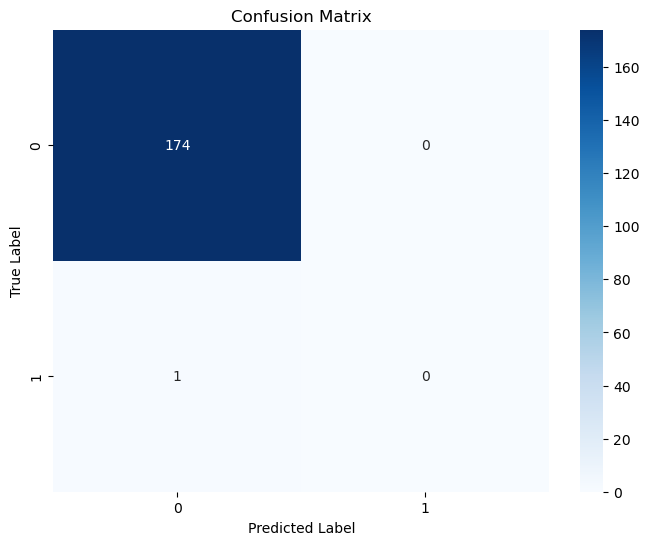

In [23]:
# Load the ONNX model
onnx_model_path = "htmlphishcnnattention.onnx"
onnx_model = onnx.load(onnx_model_path)

# Set up ONNX Runtime for inference
sess = rt.InferenceSession(onnx_model_path)

# Check the input metadata to verify the expected shape and type
input_name = sess.get_inputs()[0].name  # 'input'
input_shape = sess.get_inputs()[0].shape  # This will now be dynamic
input_type = sess.get_inputs()[0].type
print(f"Input Name: {input_name}")
print(f"Expected Input Shape: {input_shape} (Dynamic)")
print(f"Expected Input Type: {input_type}")

# Sample test data (replace with your actual test data)
X_test = test_char_padded_windows  # Test data (e.g., [batch_size, sequence_length])
y_test = test_label_windows_tensor  # Replace with actual true labels

# Ensure X_test is a numpy array and has the correct type
if not isinstance(X_test, np.ndarray):
    X_test = np.array(X_test)

X_test = X_test.astype(np.int64)  # Use int64, as the input is most likely integer token indices (for sequence data)

# Send the entire test tensor at once
print(f"Sending entire batch of shape: {X_test.shape}")
predictions = sess.run(None, {input_name: X_test})[0]

# Binarize predictions if necessary
y_pred = np.argmax(predictions, axis=1)  # Adjust based on your model's output format

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
conf_matrix = confusion_matrix(y_test, y_pred)

# Log metrics and confusion matrix in MLflow
mlflow.set_experiment("Capstone ONNX Model Metrics")

with mlflow.start_run():
    # Log the ONNX model
    mlflow.onnx.log_model(onnx_model, "onnx_model")

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.savefig("confusion_matrix.png")

    # Log confusion matrix as an artifact
    mlflow.log_artifact("confusion_matrix.png")

In [28]:
import subprocess

# Start MLflow UI in the background
subprocess.Popen(["mlflow", "ui", "--port", "5001"])

<Popen: returncode: None args: ['mlflow', 'ui', '--port', '5001']>

[2024-10-22 16:00:33 -0400] [87001] [INFO] Starting gunicorn 23.0.0
[2024-10-22 16:00:33 -0400] [87001] [INFO] Listening at: http://127.0.0.1:5001 (87001)
[2024-10-22 16:00:33 -0400] [87001] [INFO] Using worker: sync
[2024-10-22 16:00:33 -0400] [87002] [INFO] Booting worker with pid: 87002
[2024-10-22 16:00:33 -0400] [87003] [INFO] Booting worker with pid: 87003
[2024-10-22 16:00:33 -0400] [87004] [INFO] Booting worker with pid: 87004
[2024-10-22 16:00:33 -0400] [87005] [INFO] Booting worker with pid: 87005
Running the mlflow server failed. Please see the logs above for details.
[2024-10-22 16:07:55 -0400] [86716] [INFO] Parent changed, shutting down: <Worker 86716>
[2024-10-22 16:07:55 -0400] [86717] [INFO] Parent changed, shutting down: <Worker 86717>
[2024-10-22 16:07:55 -0400] [86715] [INFO] Parent changed, shutting down: <Worker 86715>
[2024-10-22 16:07:55 -0400] [86716] [INFO] Worker exiting (pid: 86716)
[2024-10-22 16:07:55 -0400] [86717] [INFO] Worker exiting (pid: 86717)
[2024